# SNR Data Exploration

RINEX gözlem dosyasından okunan SNR verilerini, seçili bir uydu için epok vs SNR olarak çizdiriyoruz.

In [3]:
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Proje kökünü Python yoluna ekle ki src.parsers import edilebilsin
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.parsers.rinex_parser import parse_rinex_obs

%matplotlib inline

In [8]:
# --- AYARLAR ---
RINEX_FILE = os.path.join(PROJECT_ROOT, "data", "PTLD00AUS_R_20220010000_01D_30S_MO.rnx")
TARGET_SAT = "G05"  # İncelenecek uydu (örn. G05, R10, E25, C03)

df, header = parse_rinex_obs(RINEX_FILE)
print(f"Toplam gözlem sayisi : {len(df)}")
print(f"Approx Position (XYZ): {header.get('approx_pos')}")
df.head()

Toplam gözlem sayisi : 482573
Approx Position (XYZ): [-3926098.9151, 3110284.571, -3935497.1153]


,epoch,constellation,satID,obsType,obsValue
0,2022-01-01,J,J03,S1C,49.1
1,2022-01-01,J,J03,S1X,52.1
2,2022-01-01,J,J03,S1Z,49.9
3,2022-01-01,J,J03,S2X,51.7
4,2022-01-01,C,C60,S2I,36.5


In [9]:
# Seçili uyduyu filtrele
sat_df = df[df["satID"] == TARGET_SAT].sort_values("epoch")

print(f"{TARGET_SAT} için gözlem sayisi : {len(sat_df)}")
print(f"Mevcut SNR tipleri          : {sorted(sat_df['obsType'].unique())}")
sat_df.head()

G05 için gözlem sayisi : 3346
Mevcut SNR tipleri          : ['S1C', 'S2W', 'S2X']


,epoch,constellation,satID,obsType,obsValue
145,2022-01-01 00:00:00,G,G05,S1C,41.6
146,2022-01-01 00:00:00,G,G05,S2W,29.7
147,2022-01-01 00:00:00,G,G05,S2X,41.7
321,2022-01-01 00:00:30,G,G05,S1C,42.2
322,2022-01-01 00:00:30,G,G05,S2W,29.9


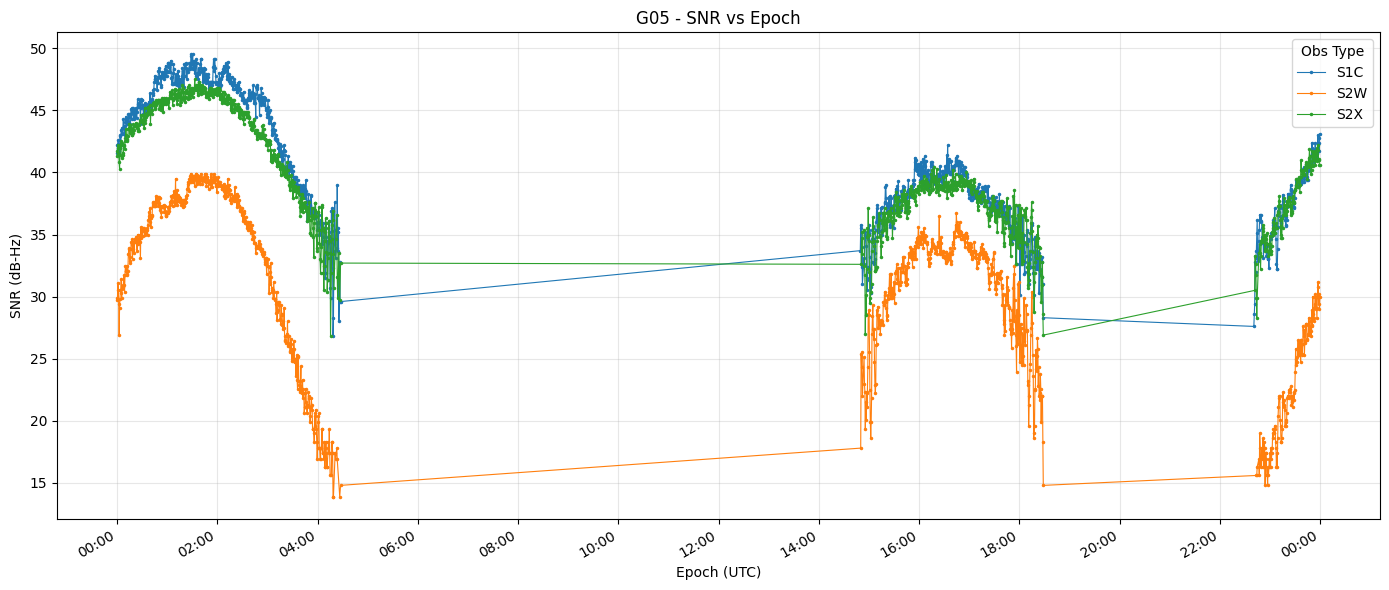

In [10]:
# --- Epoch vs SNR (tüm SNR tipleri üst üste) ---
fig, ax = plt.subplots(figsize=(14, 6))

for obs_type, group in sat_df.groupby("obsType"):
    ax.plot(
        group["epoch"],
        group["obsValue"],
        marker=".",
        linestyle="-",
        markersize=3,
        linewidth=0.8,
        label=obs_type,
    )

ax.set_title(f"{TARGET_SAT} - SNR vs Epoch")
ax.set_xlabel("Epoch (UTC)")
ax.set_ylabel("SNR (dB-Hz)")
ax.grid(True, alpha=0.3)
ax.legend(title="Obs Type", loc="best")

ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()